# CTO Line Parameter Optimization with optim_func_params

This notebook demonstrates how to use the `optim.optim_func_params` module to optimize CTO Line strategy parameters.

**Key Features:**
- Grid search over CTO parameters (v1, m1, m2, v2)
- Optimize for Sharpe, Calmar, Total Return, or Profit Factor
- Pivot table visualization for 2D parameter heatmaps

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

%matplotlib inline

## 1. Import Optimizer and Strategy Components

In [2]:
from optim import grid_search, OptimMetric, create_alloc_backtest_func
from strat.s_cto_line import compute_cto_line_allocations
from backtest import run_full_backtest, compute_strategy_metrics

ImportError: cannot import name 'compute_strategy_metrics' from 'backtest.backtest_utils' (/app/backtest/backtest_utils.py)

## 2. Load Data Bundle

In [ ]:
BUNDLE_PATH = Path().resolve().parent.parent / 'data' / 'bundle' / 'test_etf_features_bundle.parquet'

if BUNDLE_PATH.exists():
    df_bundle = pd.read_parquet(BUNDLE_PATH)
    print(f"Bundle shape: {df_bundle.shape}")
else:
    print(f"Bundle not found at {BUNDLE_PATH}")
    print("Using synthetic data for demonstration...")
    
    # Generate synthetic data for demo
    np.random.seed(42)
    n_rows = 1000
    assets = ['SPY', 'TLT', 'GLD', 'QQQ']
    
    data = {'i_minute_i': np.arange(n_rows)}
    for asset in assets:
        base_price = 100 + np.cumsum(np.random.randn(n_rows) * 0.3)
        noise = np.random.randn(n_rows) * 0.1
        data[f'{asset}_S_open_f32'] = base_price + noise
        data[f'{asset}_S_high_f32'] = base_price + np.abs(noise) + 0.5
        data[f'{asset}_S_low_f32'] = base_price - np.abs(noise) - 0.5
        data[f'{asset}_S_close_f32'] = base_price
        data[f'{asset}_S_volume_f64'] = np.random.randint(1000, 10000, n_rows).astype(float)
    
    df_bundle = pd.DataFrame(data)
    print(f"Synthetic data shape: {df_bundle.shape}")

df_bundle.head()

In [3]:
def get_asset_symbols(df: pd.DataFrame) -> list:
    symbols = set()
    for col in df.columns:
        if '_S_close_f32' in col:
            symbols.add(col.split('_')[0])
    return sorted(symbols)

ASSET_LIST = get_asset_symbols(df_bundle)
print(f"Assets: {ASSET_LIST}")

DEFAULT_ASSET = 'TLT' if 'TLT' in ASSET_LIST else ASSET_LIST[0]
print(f"Default asset: {DEFAULT_ASSET}")

NameError: name 'df_bundle' is not defined

## 3. Define Allocation Function for Optimization

The allocation function takes (df, params) and returns a DataFrame with `A_{asset}_alloc` columns.

In [4]:
def cto_line_alloc_func(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """
    CTO Line allocation function for optimization.
    
    Args:
        df: DataFrame with OHLC data
        params: Dict with keys:
            - v1, v2: SMMA periods
            - min_holding: minimum holding periods
    
    Returns:
        DataFrame with A_{asset}_alloc columns
    """
    df = df.copy()
    
    cto_params = (
        params['v1'],
        1.3*params['v1'], 
        params['v2'],
        1.2*params['v2']
    )
    
    min_holding = params.get('min_holding', 0)
    
    df = compute_cto_line_allocations(
        p_df=df,
        p_asset_list=ASSET_LIST,
        p_cto_params=cto_params,
        p_direction='both',
        p_min_holding_periods=min_holding,
        p_default_asset=DEFAULT_ASSET,
    )
    
    return df



## 4. Create Optimizer Function

Wrap the allocation function with `create_alloc_backtest_func` to get a function that returns metrics.

In [13]:
optim_func = create_alloc_backtest_func(
    alloc_func=cto_line_alloc_func,
    asset_list=ASSET_LIST,
    transaction_cost_pct=0.1,  # 0.1% transaction cost
)

print("Optimizer function created successfully!")

Optimizer function created successfully!


## 5. Test Single Parameter Set

In [44]:
test_params = {
    'v1': 400,
    'v2': 2200,
    'min_holding': 100,
}

test_metrics = optim_func(df_bundle.copy(), test_params)

print("Test metrics:")
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Test metrics:
  total_return: 10.0487
  total_return_pct: 1004.8653
  pnl_per_bar: 0.0001
  pnl_per_month: 0.1504
  cum_pnl_final: 10.0487
  final_portfolio_value: 1104.8653
  max_drawdown: -0.3091
  max_dd_pct: -30.9138
  sharpe_ratio: 1.5924
  calmar_ratio: 1.1405
  profit_factor: 1.0678
  win_rate: 0.5270
  n_bars: 48107
  n_positive_bars: 25354
  n_negative_bars: 22616
  avg_win: 0.0016
  avg_loss: -0.0017
  avg_win_loss_ratio: 0.9525
  n_trades: 512


## 6. Run Grid Search Optimization

Optimize over v1 and m1 parameters while keeping others fixed.

In [22]:
param_ranges = {
    'v1': list(range(100, 3000, 50)),
    'v2': list(range(100, 3000, 50)),  # fixed
    'min_holding': [100],
}

print(f"Total combinations: {4 * 3 * 1 * 1 * 2} = 24")

Total combinations: 24 = 24


In [23]:

df_calib = df_bundle[:20000]

results_df, best_result, pivot_df = grid_search(
    func=optim_func,
    df=df_calib,
    param_ranges=param_ranges,
    optim_metric=OptimMetric.TOTAL_RETURN,
    maximize=True,
    verbose=True,
)

Running grid search with 3364 parameter combinations...
  Progress: 336/3364
  Progress: 672/3364
  Progress: 1008/3364
  Progress: 1344/3364
  Progress: 1680/3364
  Progress: 2016/3364
  Progress: 2352/3364
  Progress: 2688/3364
  Progress: 3024/3364
  Progress: 3360/3364
Best result: {'v1': np.int64(400), 'v2': np.int64(2200), 'min_holding': np.int64(100)}
Best TOTAL_RETURN: 2.7585


## 7. View Results

In [25]:
print("\n=== Top 5 Results by Sharpe ===")
top5 = results_df.nlargest(5, 'sharpe_ratio')[['v1','v2', 'min_holding', 'sharpe_ratio', 'calmar_ratio', 'total_return', 'profit_factor']]
display(top5)

print("\n=== Best Result ===")
print(f"Params: {best_result.params}")
print(f"Sharpe: {best_result.sharpe:.4f}")
print(f"Calmar: {best_result.calmar:.4f}")
print(f"Total Return: {best_result.total_return:.4f}")
print(f"Profit Factor: {best_result.profit_factor:.4f}")


=== Top 5 Results by Sharpe ===


,v1,v2,min_holding,sharpe_ratio,calmar_ratio,total_return,profit_factor
390,400,2200,100,1.927018,2.948726,2.758539,1.080857
391,400,2250,100,1.879085,2.847441,2.619511,1.078557
627,600,2450,100,1.870525,2.585346,2.315321,1.078270
796,750,2200,100,1.857706,2.240224,2.349532,1.077525
633,600,2750,100,1.854290,2.542951,2.260977,1.077359



=== Best Result ===
Params: {'v1': np.int64(400), 'v2': np.int64(2200), 'min_holding': np.int64(100)}
Sharpe: 1.9270
Calmar: 2.9487
Total Return: 2.7585
Profit Factor: 1.0809


,QQQ_S_open_f32,QQQ_S_high_f32,QQQ_S_low_f32,QQQ_S_close_f32,QQQ_S_volume_f64,QQQ_S_open_time_i,QQQ_S_close_time_i,QQQ_minute_diff,QQQ_gap_flag,QQQ_valid_row,QQQ_factor_f32,QQQ_F_mid_f32,QQQ_F_mid2_f32,QQQ_F_LR_mid_f16,QQQ_F_LR_close_f16,QQQ_F_LR_mid2_f16,QQQ_F_range_f16,QQQ_F_return_close_f16,QQQ_F_vol_F_mid_f32_15_f16,QQQ_F_vol_F_mid_f32_60_f16,QQQ_F_delta_rel_F_mid_f32_60_f16,QQQ_F_delta_rel_F_mid_f32_120_f16,QQQ_F_delta_rel_F_mid_f32_180_f16,QQQ_F_delta_rel_F_mid_f32_240_f16,QQQ_F_delta_rel_F_mid_f32_300_f16,QQQ_F_delta_rel_F_mid_f32_360_f16,QQQ_F_delta_rel_F_mid_f32_420_f16,QQQ_F_delta_rel_F_mid_f32_480_f16,QQQ_F_delta_rel_F_mid_f32_540_f16,QQQ_F_delta_rel_F_mid_f32_600_f16,QQQ_F_delta_rel_F_mid_f32_660_f16,QQQ_F_delta_rel_F_mid_f32_720_f16,QQQ_F_delta_rel_F_mid_f32_780_f16,QQQ_F_delta_rel_F_mid_f32_840_f16,QQQ_F_delta_rel_F_mid_f32_900_f16,QQQ_F_delta_rel_F_mid_f32_960_f16,QQQ_F_delta_rel_F_mid_f32_1020_f16,QQQ_F_delta_rel_F_mid_f32_1080_f16,QQQ_F_delta_rel_F_mid_f32_1140_f16,QQQ_F_delta_rel_F_mid_f32_1200_f16,QQQ_F_delta_rel_F_mid_f32_1260_f16,QQQ_F_delta_rel_F_mid_f32_1320_f16,QQQ_F_delta_rel_F_mid_f32_1380_f16,QQQ_F_delta_rel_F_mid_f32_1440_f16,QQQ_F_delta_rel_F_mid_f32_1500_f16,QQQ_F_delta_rel_F_mid_f32_1560_f16,QQQ_F_delta_rel_F_mid_f32_1620_f16,QQQ_F_delta_rel_F_mid_f32_1680_f16,QQQ_F_delta_rel_F_mid_f32_1740_f16,QQQ_F_delta_rel_F_mid_f32_1800_f16,QQQ_F_delta_rel_F_mid_f32_1860_f16,QQQ_F_delta_rel_F_mid_f32_1920_f16,QQQ_F_delta_rel_F_mid_f32_1980_f16,QQQ_F_delta_rel_F_mid_f32_2040_f16,QQQ_F_delta_rel_F_mid_f32_2100_f16,QQQ_F_delta_rel_F_mid_f32_2160_f16,QQQ_F_delta_rel_F_mid_f32_2220_f16,QQQ_F_delta_rel_F_mid_f32_2280_f16,QQQ_F_delta_rel_F_mid_f32_2340_f16,QQQ_F_delta_rel_F_mid_f32_2400_f16,QQQ_F_delta_rel_F_mid_f32_2460_f16,QQQ_F_delta_rel_F_mid_f32_2520_f16,QQQ_F_delta_rel_F_mid_f32_2580_f16,QQQ_F_delta_rel_F_mid_f32_2640_f16,QQQ_F_delta_rel_F_mid_f32_2700_f16,QQQ_F_delta_rel_F_mid_f32_2760_f16,QQQ_F_delta_rel_F_mid_f32_2820_f16,QQQ_F_delta_rel_F_mid_f32_2880_f16,QQQ_F_delta_rel_F_mid_f32_2940_f16,QQQ_F_delta_rel_F_mid_f32_3000_f16,QQQ_F_delta_rel_F_mid_f32_3060_f16,QQQ_F_delta_rel_F_mid_f32_3120_f16,QQQ_F_delta_rel_F_mid_f32_3180_f16,QQQ_F_delta_rel_F_mid_f32_3240_f16,QQQ_F_delta_rel_F_mid_f32_3300_f16,QQQ_F_delta_rel_F_mid_f32_3360_f16,QQQ_F_delta_rel_F_mid_f32_3420_f16,QQQ_F_delta_rel_F_mid_f32_3480_f16,QQQ_F_delta_rel_F_mid_f32_3540_f16,QQQ_F_delta_rel_F_mid_f32_3600_f16,QQQ_F_delta_rel_F_mid_f32_3660_f16,QQQ_F_delta_rel_F_mid_f32_3720_f16,QQQ_F_delta_rel_F_mid_f32_3780_f16,QQQ_F_delta_rel_F_mid_f32_3840_f16,QQQ_F_delta_rel_F_mid_f32_3900_f16,QQQ_F_delta_rel_F_mid_f32_3960_f16,QQQ_F_delta_rel_F_mid_f32_4020_f16,QQQ_F_delta_rel_F_mid_f32_4080_f16,QQQ_F_delta_rel_F_mid_f32_4140_f16,QQQ_F_delta_rel_F_mid_f32_4200_f16,QQQ_F_delta_rel_F_mid_f32_4260_f16,QQQ_F_delta_rel_F_mid_f32_4320_f16,QQQ_F_rsi_2_F_mid_f32_f16,QQQ_F_rsi_15_F_mid_f32_f16,QQQ_F_rsi_60_F_mid_f32_f16,QQQ_F_rsi_240_F_mid_f32_f16,QQQ_F_rsi_500_F_mid_f32_f16,QQQ_F_rsi_1440_F_mid_f32_f16,QQQ_F_rsi_2880_F_mid_f32_f16,QQQ_F_ema_2_F_mid_f32_f32,QQQ_F_ema_15_F_mid_f32_f32,QQQ_F_ema_60_F_mid_f32_f32,QQQ_F_ema_240_F_mid_f32_f32,QQQ_F_ema_500_F_mid_f32_f32,QQQ_F_ema_1440_F_mid_f32_f32,QQQ_F_ema_2880_F_mid_f32_f32,QQQ_F_delta_rel_ema_2_15_F_mid_f32_f16,QQQ_F_delta_rel_ema_15_60_F_mid_f32_f16,QQQ_F_delta_rel_ema_60_240_F_mid_f32_f16,QQQ_F_delta_rel_ema_240_500_F_mid_f32_f16,QQQ_F_delta_rel_ema_500_1440_F_mid_f32_f16,QQQ_F_delta_rel_ema_1440_2880_F_mid_f32_f16,QQQ_F_diff_rel_ema_2_F_mid_f32_2_f16,QQQ_F_diff_rel_ema_2_F_mid_f32_15_f16,QQQ_F_diff_rel_ema_2_F_mid_f32_60_f16,QQQ_F_diff_rel_ema_2_F_mid_f32_240_f16,QQQ_F_diff_rel_ema_2_F_mid_f32_500_f16,QQQ_F_diff_rel_ema_2_F_mid_f32_1440_f16,QQQ_F_acc_dist_index_f64,QQQ_F_roc_14_F_mid_f32_f16,QQQ_F_roc_60_F_mid_f32_f16,QQQ_F_roc_240_F_mid_f32_f16,i_minute_i,SPY_S_open_f32,SPY_S_high_f32,SPY_S_low_f32,SPY_S_close_f32,SPY_S_volume_f64,SPY_S_open_time_i,SPY_S_close_time_i,SPY_minute_diff,SPY_gap_flag,SPY_valid_row,SPY_f

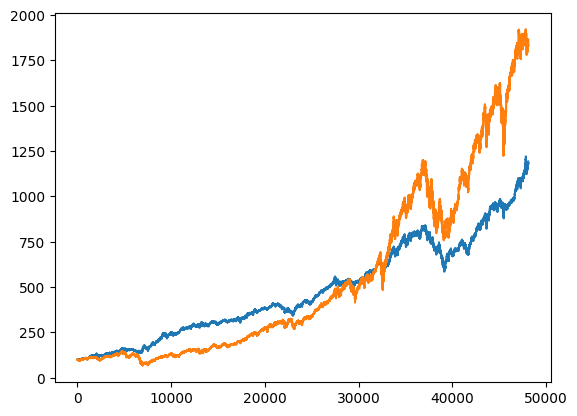

In [38]:
test_params = {
    'v1': 400,
    'v2': 2200,
    'min_holding': 100,
}
from backtest.backtest_basket_alloc_based import run_full_backtest

def cto_line_pnl(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """
    CTO Line allocation function for optimization.
    
    Args:
        df: DataFrame with OHLC data
        params: Dict with keys:
            - v1, v2: SMMA periods
            - min_holding: minimum holding periods
    
    Returns:
        DataFrame with A_{asset}_alloc columns
    """
    df = df.copy()
    
    cto_params = (
        params['v1'],
        1.3*params['v1'], 
        params['v2'],
        1.2*params['v2']
    )
    
    min_holding = params.get('min_holding', 0)
    
    df = compute_cto_line_allocations(
        p_df=df,
        p_asset_list=ASSET_LIST,
        p_cto_params=cto_params,
        p_direction='both',
        p_min_holding_periods=min_holding,
        p_default_asset=DEFAULT_ASSET,
    )
    df, orders_df = run_full_backtest(p_df=df, p_asset_list=ASSET_LIST,transaction_cost_pct = 0.01)

    df['port_value'].plot()
    df['qqq_norm'] = df['QQQ_S_close_f32']/39.02*100
    df['qqq_norm'].plot()
    
    return df

cto_line_pnl(df_bundle,test_params)

In [34]:
df_bundle.columns

df_bundle['QQQ_S_close_f32']

0         39.023914
1         38.722614
2         38.681034
3         38.836868
4         38.992699
            ...    
48102    717.620728
48103    716.077759
48104    715.253235
48105    715.064819
48106    714.805664
Name: QQQ_S_close_f32, Length: 48107, dtype: float32

In [32]:
# Show pivot table (if 2D optimization)
if not pivot_df.empty:
    print("\n=== Pivot Table (Sharpe by v1 vs m1, min_holding=0) ===")
    display(pivot_df.round(3))

## 8. Heatmap Visualization

In [27]:
if not pivot_df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax)
    ax.set_title('Sharpe Ratio: v1 vs m1')
    ax.set_xlabel('v1')
    ax.set_ylabel('m1')
    plt.tight_layout()
    plt.show()

## 9. Optimize for Different Metrics

In [ ]:
# Optimize for Calmar Ratio instead
results_calmar, best_calmar, _ = grid_search(
    func=optim_func,
    df=df_bundle,
    param_ranges=param_ranges,
    optim_metric=OptimMetric.CALMAR,
    maximize=True,
    verbose=False,
)

print("Best by Calmar:")
print(f"  Params: {best_calmar.params}")
print(f"  Calmar: {best_calmar.calmar:.4f}")
print(f"  Sharpe: {best_calmar.sharpe:.4f}")

In [ ]:
# Optimize for Total Return
results_return, best_return, _ = grid_search(
    func=optim_func,
    df=df_bundle,
    param_ranges=param_ranges,
    optim_metric=OptimMetric.TOTAL_RETURN,
    maximize=True,
    verbose=False,
)

print("Best by Total Return:")
print(f"  Params: {best_return.params}")
print(f"  Total Return: {best_return.total_return:.4f}")
print(f"  Sharpe: {best_return.sharpe:.4f}")

## 10. Compare Optimization Results

In [ ]:
comparison = pd.DataFrame([
    {'metric': 'Sharpe', **best_result.params, 'sharpe': best_result.sharpe, 'calmar': best_result.calmar, 'return': best_result.total_return},
    {'metric': 'Calmar', **best_calmar.params, 'sharpe': best_calmar.sharpe, 'calmar': best_calmar.calmar, 'return': best_calmar.total_return},
    {'metric': 'Return', **best_return.params, 'sharpe': best_return.sharpe, 'calmar': best_return.calmar, 'return': best_return.total_return},
])

print("\n=== Comparison of Best Results by Different Metrics ===")
display(comparison)

## 11. Full Results Export

In [ ]:
# Export all results to CSV
output_path = Path().resolve().parent / 'backtest_results' / 'cto_line_optimization_results.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")